In [8]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from utilities.constants import (COLUMNS_RENAME_MAPPING, CONTINUOUS_COLUMNS, CATEGORICAL_COLUMNS)

In [3]:
dataset = pd.read_excel("data\Training.xlsx")
dataset.drop(columns='ID', inplace=True)
dataset.rename(columns=COLUMNS_RENAME_MAPPING, inplace=True)
dataset["gender"] = dataset["gender"].str.strip().str.lower()

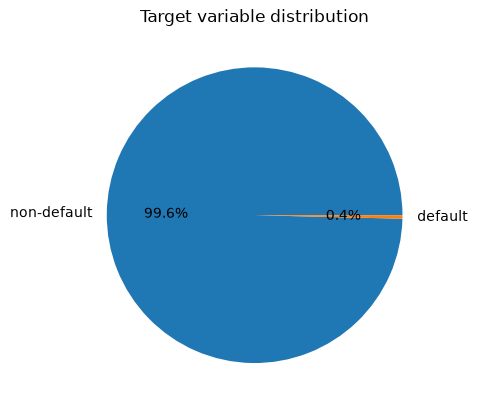

In [4]:
plt.pie(
    dataset['target'].value_counts(),
    labels=['non-default', 'default'],
    autopct="%1.1f%%"
)
plt.title("Target variable distribution")
plt.show()

Бачым вялікі дысбаланс па класам у мэтавай пераменнай. На аднаго дэфолтнага кліента прыходзіцца прыблізна 263 не дефолтных.

Для ацэнкі якасці мадэляў варта выкарыстоўваць метрыкі, падыходзячыя для несбалансаваных выпадкаў. Таксама, лічу што выявіць дэфолтнага кліента важней, чым няправільна вызначыць недэфолтнага, бо ў першым выпадку мы губляем ўсё цела крэдыта, у другім выпадку ў якасці недаатрыманага прыбытка, мы губляем толькі працэнты па крэдыту, акрамя гэтага крыдыт можна выдаць іншаму кліенту, які выглядае больш надзейна.

З-за гэтага ў якасці асноўнай метрыкі буду выкарыстоўваць f2-меру, яна добра падыходзіць для несбалансаваных выпадкаў, і recall мае ў 4 разы большую значнасць, чым Precision. У якасці дадатковая метрыкі буду выкарыстоўваць PR-AUC.

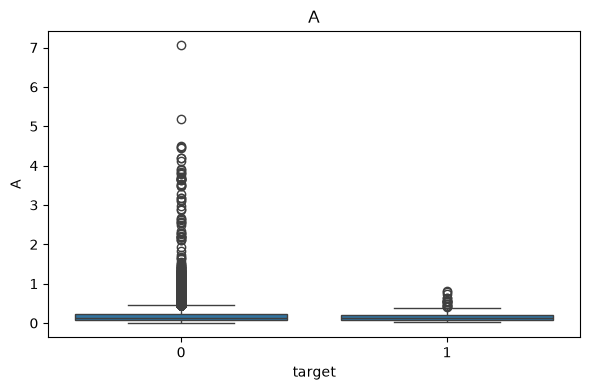

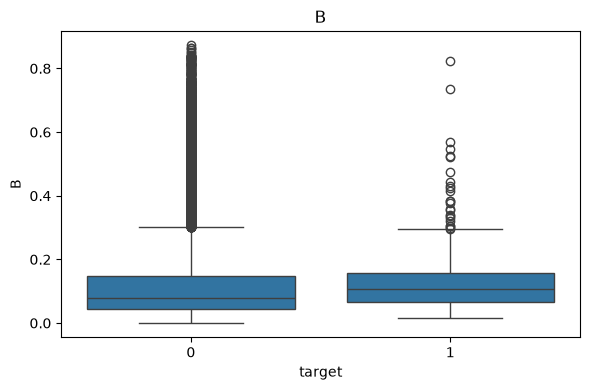

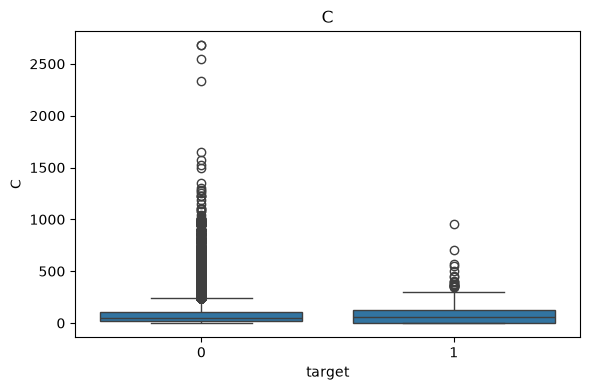

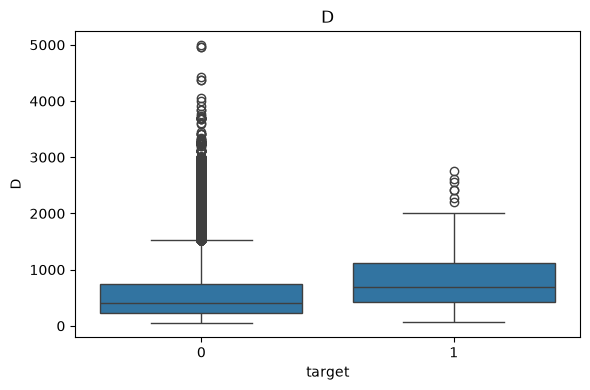

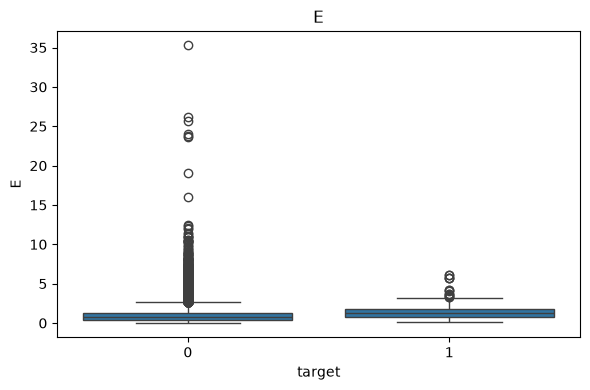

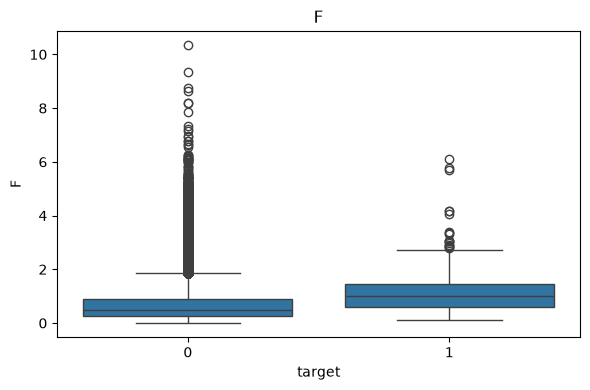

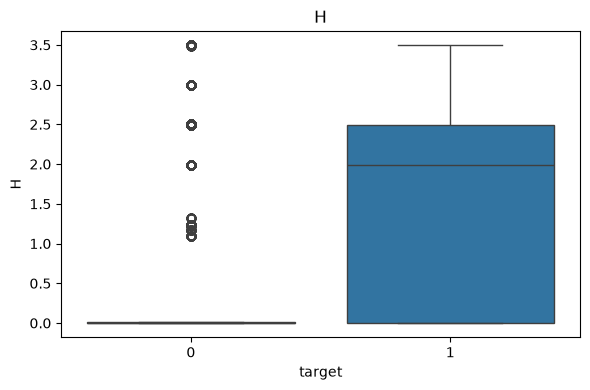

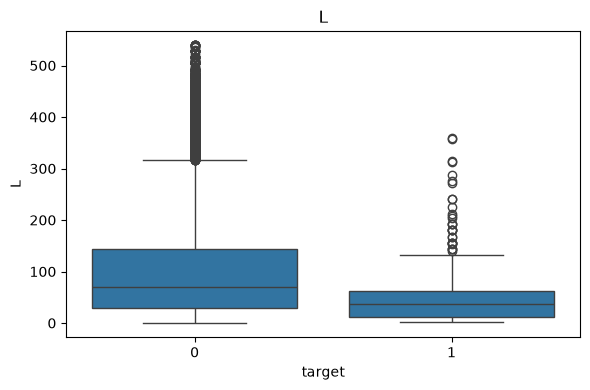

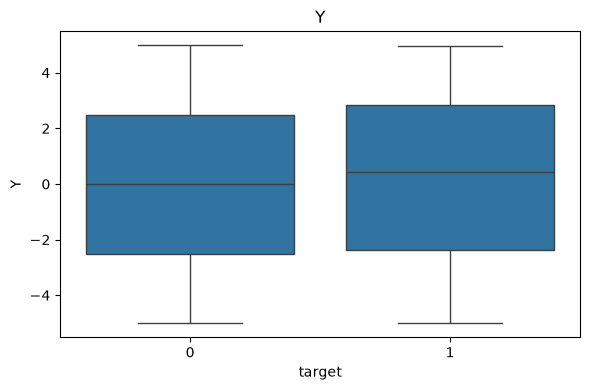

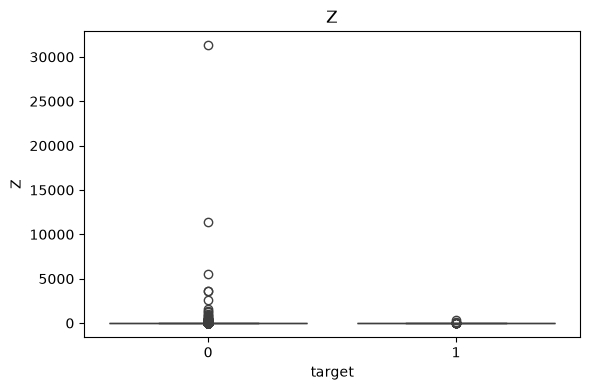

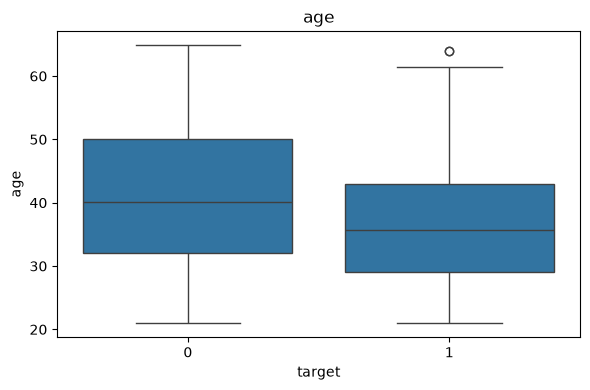

In [5]:
for feature in CONTINUOUS_COLUMNS:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=dataset,
        x='target',
        y=feature
    )

    plt.title(f'{feature}')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

Размеркаванні безперапынных прыкмет у залежнасці ад мэтавай пераменнай істотных адрозненняў не маюць, за выключэннем прыкметы 'H', дэфолтныя кліенты па прыкмеце 'H' часцей маюць больш высокія значэнні.

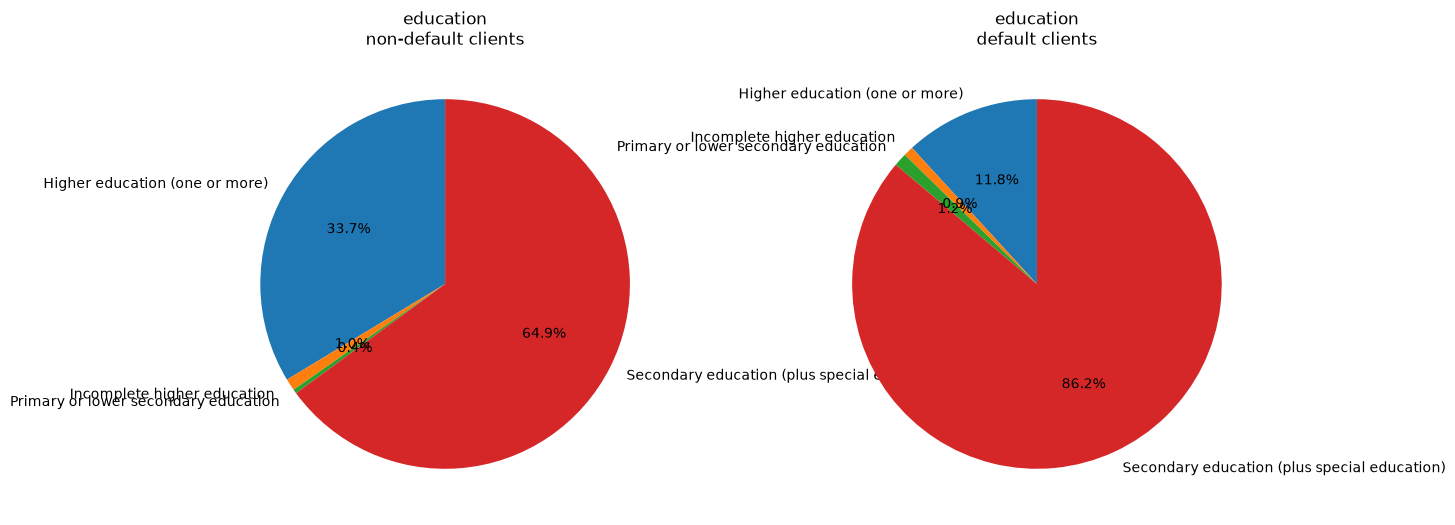

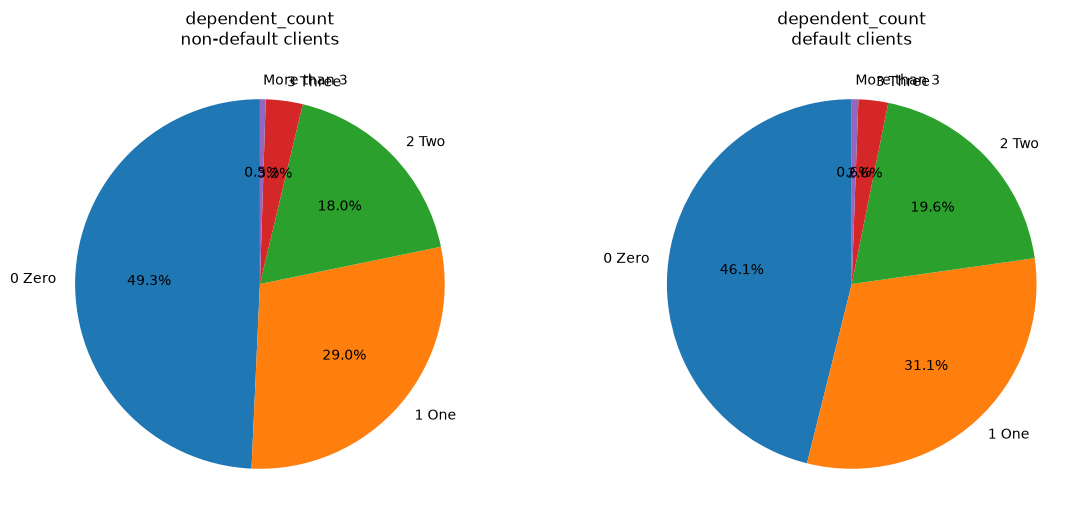

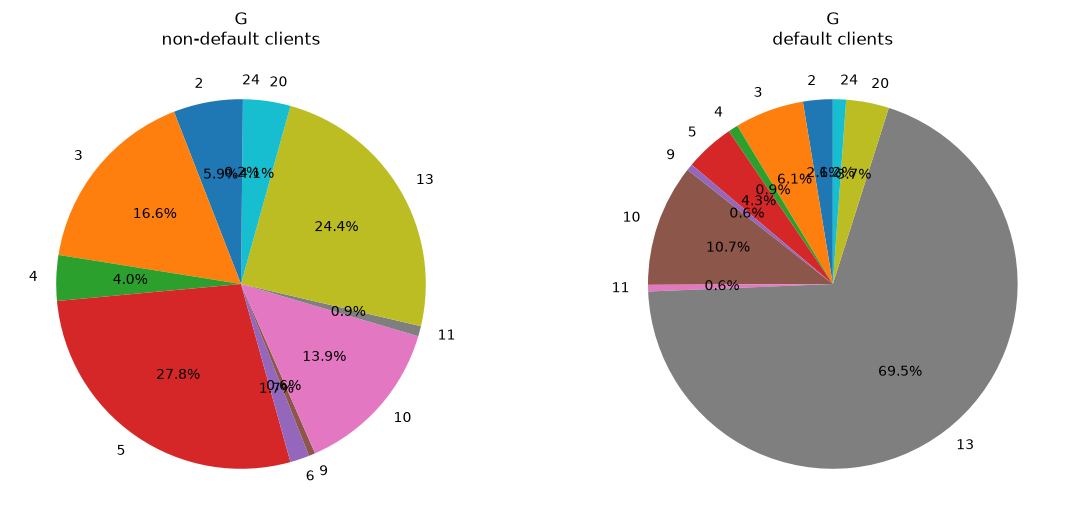

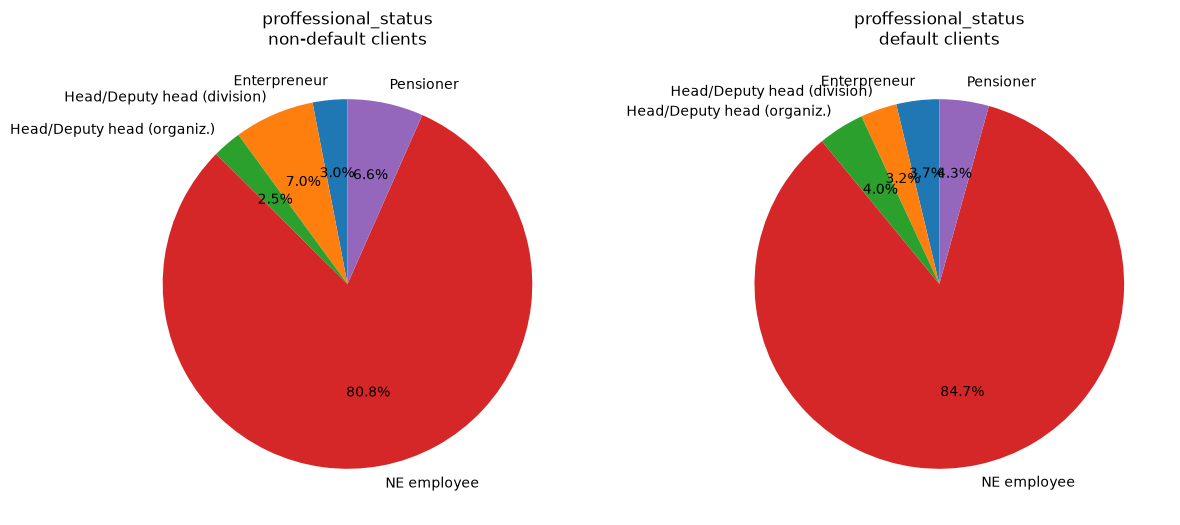

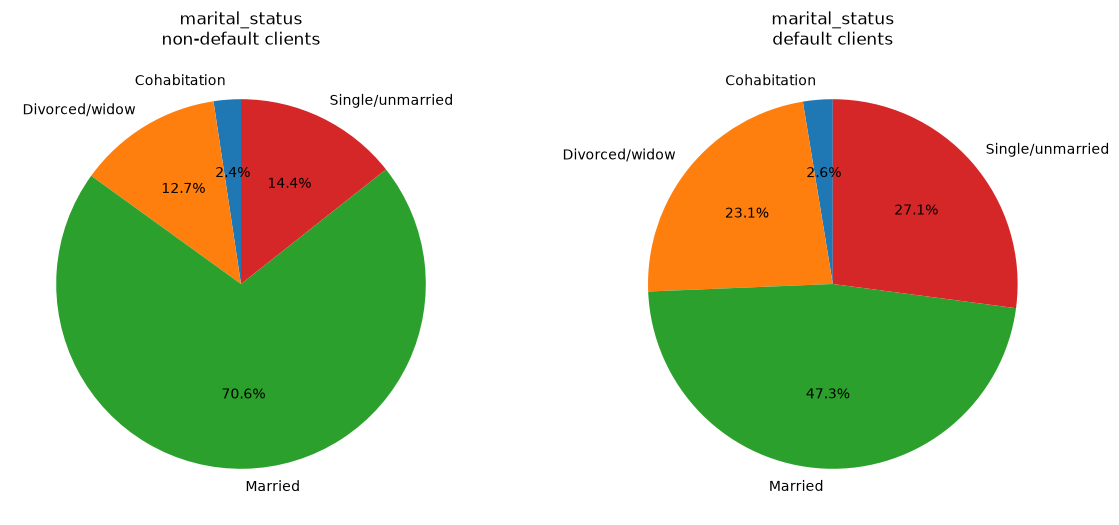

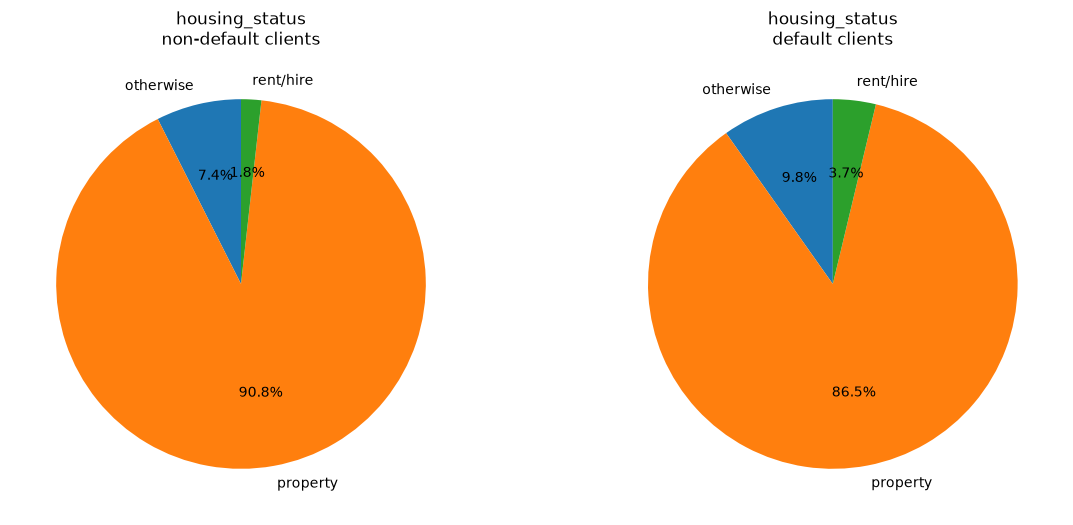

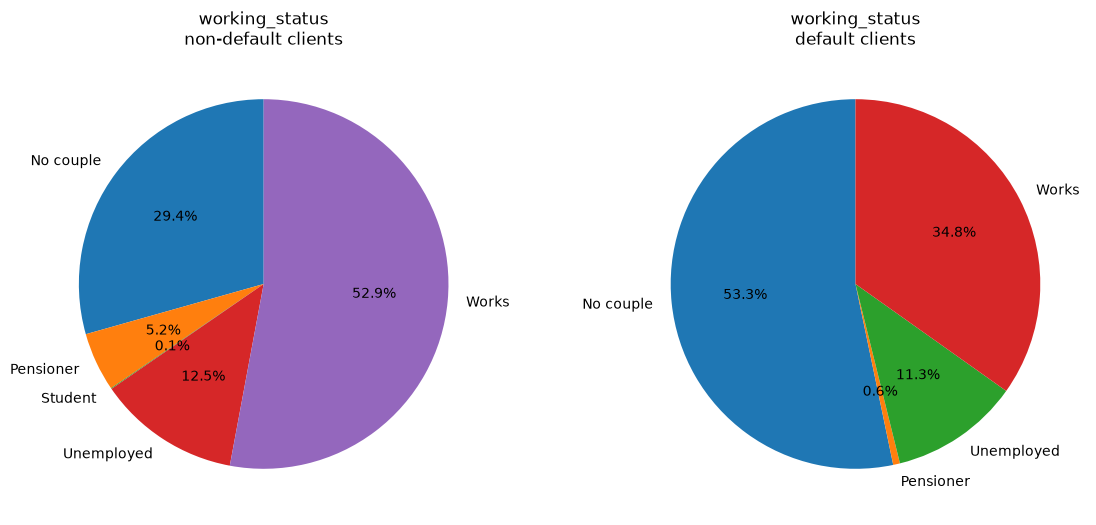

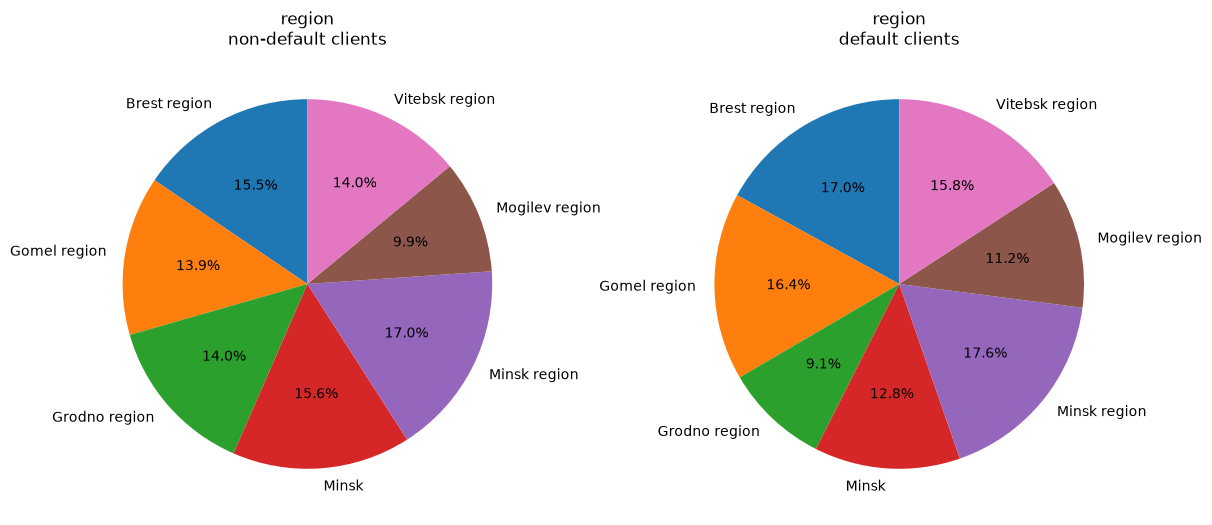

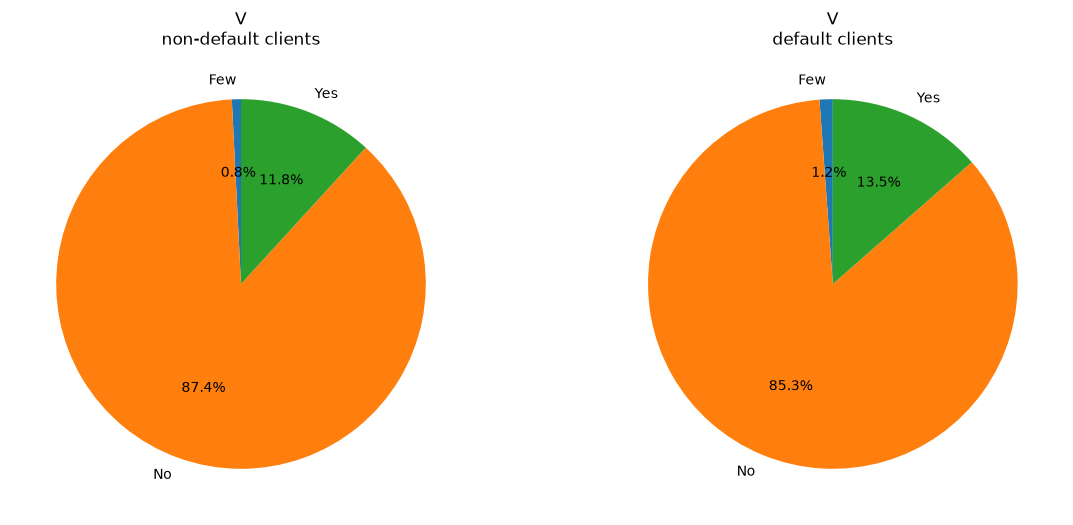

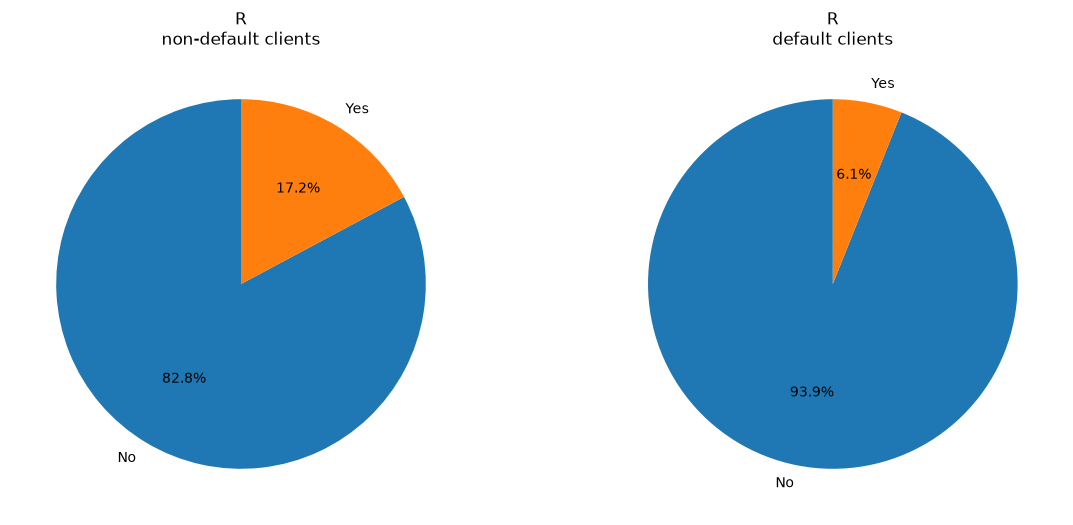

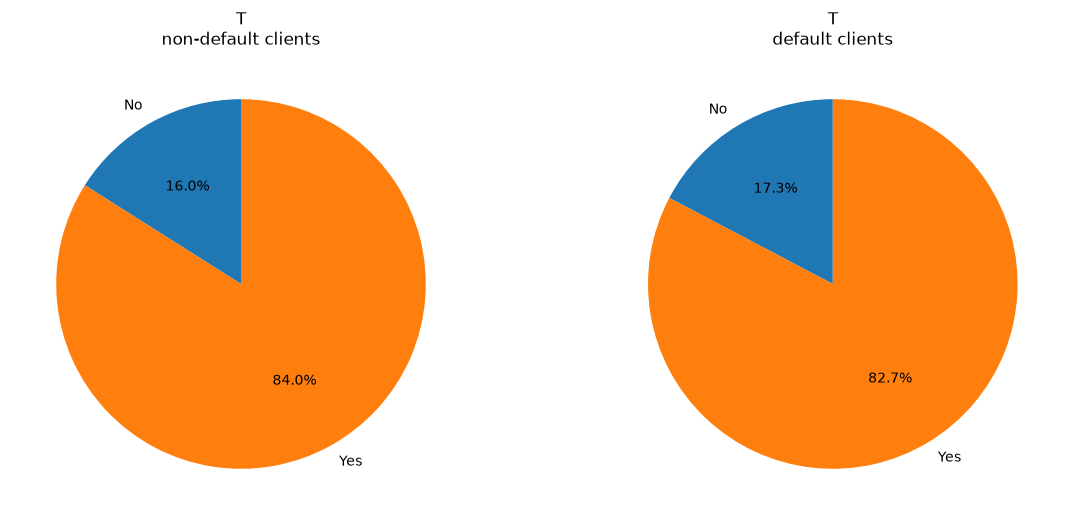

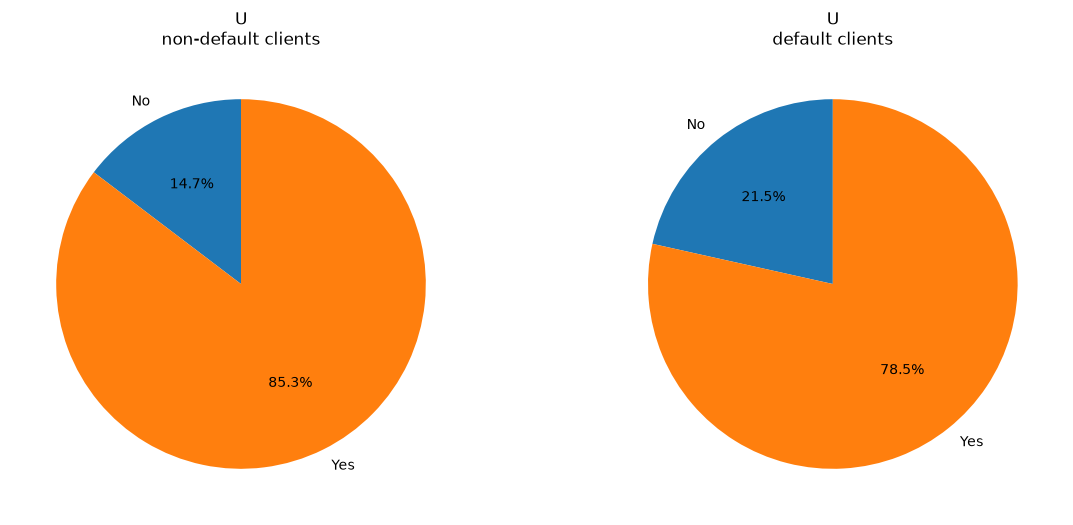

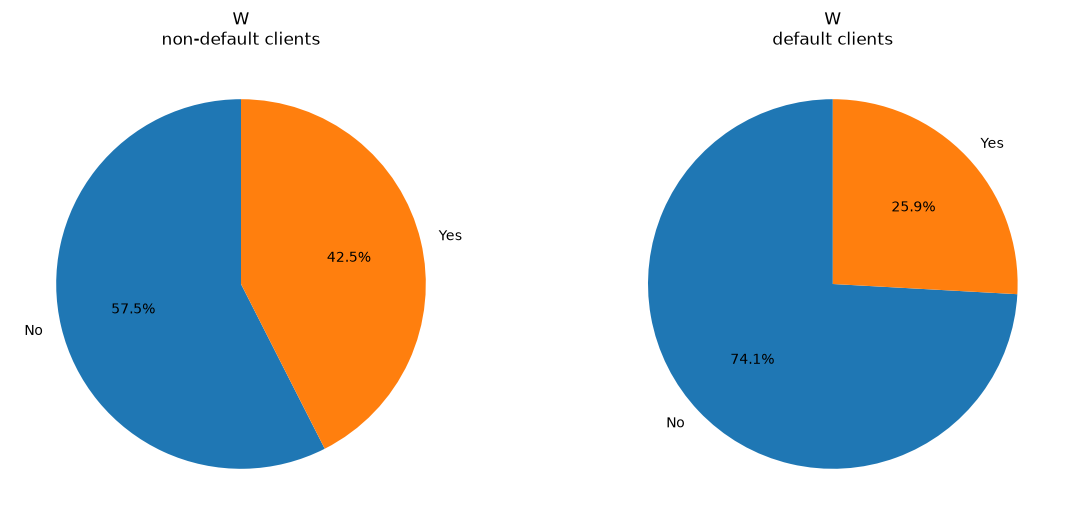

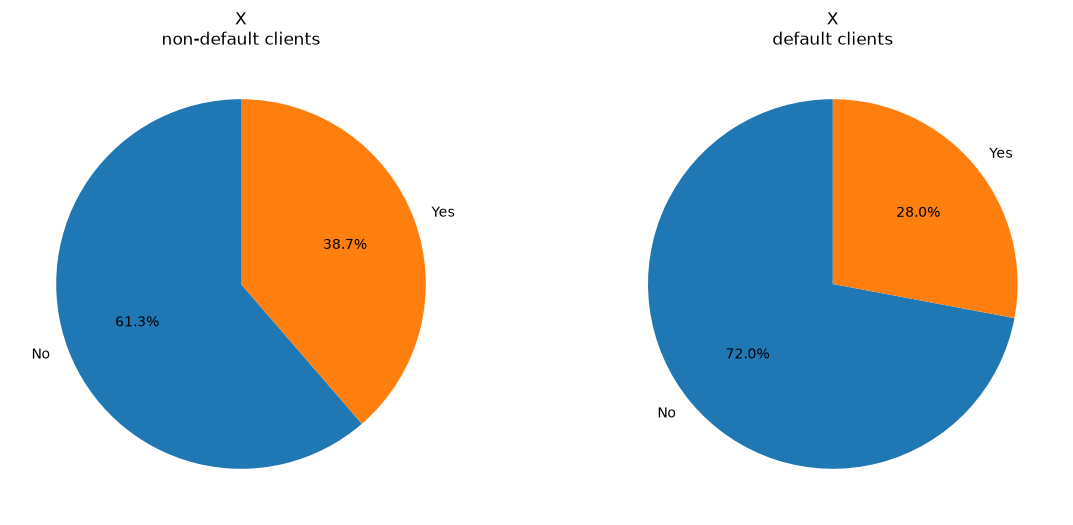

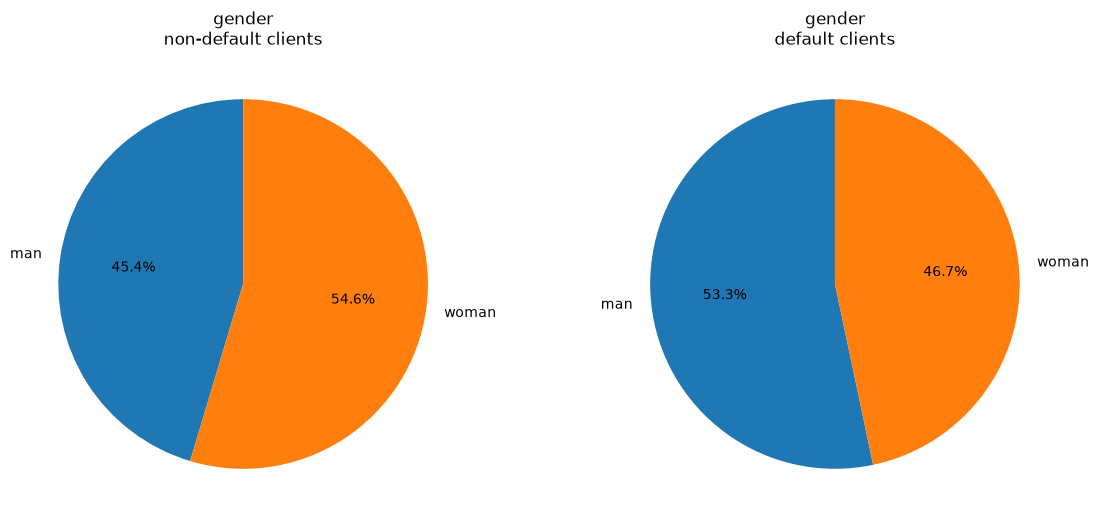

In [27]:
default_map = {
    0: 'non-default clients',
    1: 'default clients'
}

for feature in CATEGORICAL_COLUMNS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for i in range(2):
        subset = (
            dataset[dataset['target'] == i][feature]
            .value_counts()
            .sort_index()
        )

        axes[i].pie(
            subset,
            labels=subset.index,
            autopct='%1.1f%%',
            startangle=90
        )
        axes[i].set_title(f'{feature}\n{default_map[i]}')

    plt.show()

Сярод катэгарыяльных прыкмет адрозненняў больш:
1. Кліенты з вышэйшай адукацыяй часцей вяртаюць крэдыты, чым кліенты са сярэдне-спецыяльная адукацыяй
2. Вялікая дыспрапорцыя па прыкмеце 'G', сярод дэфолтных кліентаў людзі са значэннем 13 сустракаюцца куды часцей, чым у астатняй выбарцы.
3. Сярод дэфолтных кліентаў працэнт нежанатых/незамужніх і разведзеных большы.
4. Нягледзячы на тое, што жанчын сярод кліентаў трохі больш за мужчын, сярод кліентаў у дэфолце большасць ужо мужчын.
5. Таксама ёсць адрозненні ў размеркаванні па прыкметам: working_status, X, W, U, R.

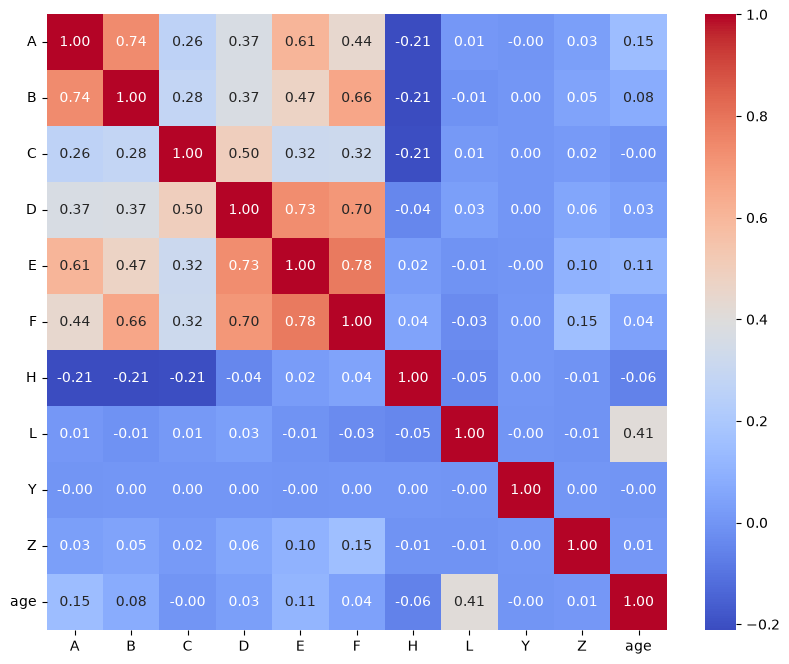

In [ ]:

correlation_matrix = dataset[CONTINUOUS_COLUMNS].corr(method='pearson')

plt.figure(figsize=(10, 8))

sns.heatmap(
    
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)

plt.yticks(rotation=0)
plt.show()

Згодна з матрыцай карэляцыі, ёсць істотная ўзаемасувязь паміж прыкметамі 'D', 'E' і 'F', а таксама 'A' і 'B', хаця абсалютнай мультыкалінеарнасці сярод безперапынных прыкмет няма. Думаю, ніякія прыкметы на гэтым этапе адкідваць не варта.